# 🔢 ANN from Scratch — MNIST Digit Recognizer — Exploratory Data Analysis

**Dataset:** Kaggle — MNIST Digit Recognizer (CSV) — 28×28 grayscale handwritten digit images
**Target:** `label` — the digit (0–9) drawn by hand
**Domain:** Deep Learning Fundamentals (NumPy-only ANN — no TensorFlow / PyTorch / Keras)
**Author:** Narendra

---

## 🎯 Business / Interview Context

This project builds a **feedforward Artificial Neural Network entirely from scratch in NumPy** — forward propagation, backpropagation, and gradient descent implemented by hand, with no deep learning framework.

**Why this matters:** Interviewers at Google, Flipkart, and quant firms use this exact exercise to separate candidates who *understand* neural networks from candidates who only know how to call `model.fit()` in Keras. Every decision in the training pipeline — normalization, weight initialization scheme, activation function, hidden layer width — has to be justified from first principles, because there is no framework default to fall back on.

**Goal of this EDA:** Unlike a tabular EDA (credit risk, fraud), the goal here is not to engineer new columns — the columns literally *are* the 784 raw pixels. The goal is to understand the **image data well enough to make correct from-scratch architecture and hyperparameter decisions**: how to normalize inputs so activations don't saturate, why naive weight initialization explodes with a 784-dimensional input, how much redundancy exists in the pixel space, and which digit pairs the network is most likely to confuse.

---

## 📌 Notebook Workflow

| Step | Topic |
|------|-------|
| 1 | Import libraries |
| 2 | Data loading and initial inspection |
| 3 | Dataset structure, data types and memory footprint |
| 4 | Missing values analysis |
| 5 | Duplicate images and train/test leakage check |
| 6 | Class (digit) distribution |
| 7 | Sample digit grid — visual sanity check |
| 8 | Mean image per class (class centroids) |
| 9 | Pixel intensity distribution and sparsity |
| 10 | Pixel-wise variance — dead pixel map |
| 11 | Spatial pixel correlation |
| 12 | Ink density (stroke thickness) by digit |
| 13 | Center-of-mass consistency check |
| 14 | Class-confusability matrix (mean-image similarity) |
| 15 | Normalization strategy and activation saturation |
| 16 | Train / validation split and stratification check |
| 17 | Label encoding — one-hot targets for softmax |
| 18 | Weight initialization — naive vs Xavier vs He |
| 19 | Dimensionality redundancy check (PCA variance) |
| 20 | Ambiguous / outlier sample detection |
| 21 | Key EDA insights and architecture design summary |

---

---
## Step 1 — Import Libraries
**Why:** All required libraries imported upfront. No deep learning framework is imported anywhere in this project — `numpy` is the only computational engine, consistent with the "from scratch" constraint. `sklearn` is used strictly for EDA utilities (PCA, train/test split) and never for the model itself.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import hashlib
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.size': 11, 'axes.titlesize': 13, 'axes.titleweight': 'bold',
})
BLUE = '#2196F3'; PINK = '#E91E63'; GRAY = '#90A4AE'; GREEN = '#4CAF50'; ORANGE = '#FF9800'
CLASS_COLORS = plt.cm.tab10(np.linspace(0, 1, 10))
RNG = np.random.RandomState(42)
print('✅ Libraries loaded successfully')

✅ Libraries loaded successfully


---
## Step 2 — Data Loading and Initial Inspection
**Why:** First look at raw data — shape, label column, and a peek at raw pixel values to confirm the 0–255 integer range before any processing.

**Business context:** The Kaggle `train.csv` (42,000 rows) and `test.csv` (28,000 rows) ship with a header row (`label,pixel0,...,pixel783` for train). Loaded with default header inference, then column names are standardized explicitly so every downstream cell can rely on the exact `label` + `pixel0`...`pixel783` naming regardless of any minor header formatting differences across dataset copies.

In [3]:
TRAIN_PATH = r"D:\Data Science Datasets\ANN from Scratch — MNIST Digit Recognizer\train.csv"
TEST_PATH  = r"D:\Data Science Datasets\ANN from Scratch — MNIST Digit Recognizer\test.csv"

df_raw      = pd.read_csv(TRAIN_PATH)
df_test_raw = pd.read_csv(TEST_PATH)

# Standardize column names to label + pixel0..pixel783. The Kaggle files
# already ship with this exact header, but this makes the notebook robust
# to any other MNIST CSV export that uses slightly different column names.
expected_cols = ['label'] + [f'pixel{i}' for i in range(784)]
for frame in (df_raw, df_test_raw):
    if frame.shape[1] == 785:
        frame.columns = expected_cols

print(f'Train shape : {df_raw.shape}')
print(f'Test shape  : {df_test_raw.shape}')
print(f"\nPixel value range in train: [{df_raw.iloc[:, 1:].values.min()}, {df_raw.iloc[:, 1:].values.max()}]")
display(df_raw.iloc[:5, :12])

Train shape : (42000, 785)
Test shape  : (28000, 784)

Pixel value range in train: [0, 255]


,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10
0,1,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0


**📌 Observation:** Train loads as 42,000 rows × 785 columns (1 `label` + 784 pixels). Test loads as 28,000 rows × **784 columns only** — Kaggle's official test set has no `label` column, since it's the unlabeled file used for competition submission. Pixel values confirmed integers in `[0, 255]`.

**💡 Pipeline decision:** Because `label` is absent from `df_test_raw`, every downstream cell that touches `df_test`/`df_test_raw` must check `'label' in df_test.columns` before referencing it, and this notebook's own train/validation split (Step 16) is built entirely out of the labeled `train.csv`, not out of the unlabeled competition test file.

---
## Step 3 — Dataset Structure, Data Types and Memory Footprint
**Why:** Pandas defaults to `int64` for every numeric column on read. Pixel values only ever need 1 byte (`0-255`), so this step checks actual memory usage and downcasts — a real consideration once the array is flattened and fed through thousands of forward/backward passes in a from-scratch training loop.

In [4]:
mem_before = df_raw.memory_usage(deep=True).sum() / 1024**2
print(f'Memory usage (int64)             : {mem_before:.1f} MB')

pixel_cols = [c for c in df_raw.columns if c.startswith('pixel')]

df = df_raw.copy()
df[pixel_cols] = df[pixel_cols].astype(np.uint8)
df['label']     = df['label'].astype(np.uint8)

# test.csv is Kaggle's unlabeled submission file -- pixel columns only,
# no 'label' column -- so only cast the columns that actually exist.
df_test = df_test_raw.copy()
test_pixel_cols = [c for c in df_test.columns if c.startswith('pixel')]
df_test[test_pixel_cols] = df_test[test_pixel_cols].astype(np.uint8)
if 'label' in df_test.columns:
    df_test['label'] = df_test['label'].astype(np.uint8)

mem_after = df.memory_usage(deep=True).sum() / 1024**2
print(f'Memory usage (uint8)             : {mem_after:.1f} MB')
print(f'Reduction                        : {(1 - mem_after/mem_before)*100:.1f}%')
print(f'\nUnique pixel column dtypes       : {df.iloc[:, 1:].dtypes.unique()}')
print(f'Unique label values               : {sorted(df["label"].unique().tolist())}')
print(f'Test set has label column         : {"label" in df_test.columns}')

Memory usage (int64)             : 251.5 MB
Memory usage (uint8)             : 31.4 MB
Reduction                        : 87.5%

Unique pixel column dtypes       : [dtype('uint8')]
Unique label values               : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Test set has label column         : False


**📌 Observation:** Downcasting from `int64` to `uint8` cuts memory from **251.5 MB to 31.4 MB — an 87.5% reduction**. All 10 label classes (0–9) are present with no unexpected values, and `df_test` correctly has no `label` column to cast (confirmed by `Test set has label column : False`).

**💡 Pipeline decision:** `uint8` is used for storage and I/O; pixel arrays are upcast to `float64`/`float32` only at the exact point of normalization (`X / 255.0`). The uint8 cast on `df_test` is applied conditionally (`if 'label' in df_test.columns`) so the same cell runs safely on both the labeled train file and the label-less Kaggle test file.

---
## Step 4 — Missing Values Analysis
**Why:** Even a clean, well-known benchmark dataset should never be assumed complete — a from-scratch NumPy pipeline has no built-in `NaN` handling, so a single missing pixel would silently propagate `NaN` through every matrix multiplication in forward propagation and corrupt the entire batch.

**Business insight:** MNIST is a curated academic benchmark, so zero missing values are expected — but the check itself is what a senior engineer includes as a defensive guardrail before trusting any input pipeline, not something to skip just because the dataset is well known.

In [5]:
missing_train = df.isnull().sum().sum()
missing_test  = df_test.isnull().sum().sum()
print(f'Missing values — train : {missing_train}')
print(f'Missing values — test  : {missing_test}')

nan_rows = df.isnull().any(axis=1).sum()
print(f'Rows with any NaN      : {nan_rows}')

Missing values — train : 0
Missing values — test  : 0
Rows with any NaN      : 0


**📌 Observation:** Zero missing values across all pixel columns in both train and test, and zero rows with any `NaN` — a clean, fully curated benchmark dataset, exactly as expected.

**💡 Pipeline decision:** No imputation logic needed. The `load_and_validate()` function still asserts `X.isnull().sum().sum() == 0` before training starts, so the pipeline fails loudly instead of silently propagating `NaN` gradients if this were ever re-run on a different, dirtier CSV export.

---
## Step 5 — Duplicate Images and Train/Test Leakage Check
**Why:** Two checks that matter more for image data than for tabular data: (1) exact duplicate rows within train, which waste compute and slightly bias gradient updates toward repeated samples, and (2) — far more important — any training image that is byte-for-byte identical to a test image, which would silently inflate test accuracy and invalidate the entire evaluation.

**Business insight:** Leakage between train and test is one of the most common reasons a "99% accuracy" model collapses in production. This check costs a few seconds and prevents reporting an inflated, untrustworthy number to stakeholders or interviewers.

In [6]:
def row_hashes(frame):
    pixel_bytes = frame.iloc[:, 1:].values.astype(np.uint8).tobytes()
    n, d = frame.shape[0], frame.shape[1] - 1
    arr = frame.iloc[:, 1:].values.astype(np.uint8)
    return pd.util.hash_pandas_object(pd.DataFrame(arr), index=False)

train_hashes = row_hashes(df)
test_hashes  = row_hashes(df_test)

dupes_in_train = train_hashes.duplicated().sum()
overlap        = pd.Series(train_hashes).isin(set(test_hashes.values)).sum()

print(f'Exact duplicate images within train      : {dupes_in_train}')
print(f'Train images identical to a test image   : {overlap}')

Exact duplicate images within train      : 0
Train images identical to a test image   : 0


**📌 Observation:** **Zero exact duplicate images within train** and **zero train images identical to a test image** — this specific copy of the data has no internal duplication and no train/test leakage at all.

**💡 Pipeline decision:** No rows are dropped in the dedup step for this dataset (confirmed by "Rows before dedup: 42000 / Rows after dedup: 42000"), but the `row_hashes()` + `duplicated()` check is kept as a permanent guardrail in the pipeline rather than removed, since it costs a few seconds and would catch leakage immediately if the source CSV export ever changed.

In [7]:
dupe_mask = pd.Series(train_hashes).duplicated()
print(f'Rows before dedup : {len(df)}')
df = df.loc[~dupe_mask.values].reset_index(drop=True)
print(f'Rows after dedup  : {len(df)}')

Rows before dedup : 42000
Rows after dedup  : 42000


---
## Step 6 — Class (Digit) Distribution
**Why:** Unlike the credit-risk (9.4:1) and fraud-detection (>400:1) datasets, MNIST's class balance directly decides whether accuracy is a trustworthy metric on its own, or whether the from-scratch training loop needs class weighting.

**Business insight:** If digits are roughly evenly represented, plain accuracy and a standard softmax + cross-entropy loss (equal weight per class) are appropriate — a much simpler setup than the SMOTE/SMOTENC + F1/PR-AUC machinery required for the imbalanced tabular problems.

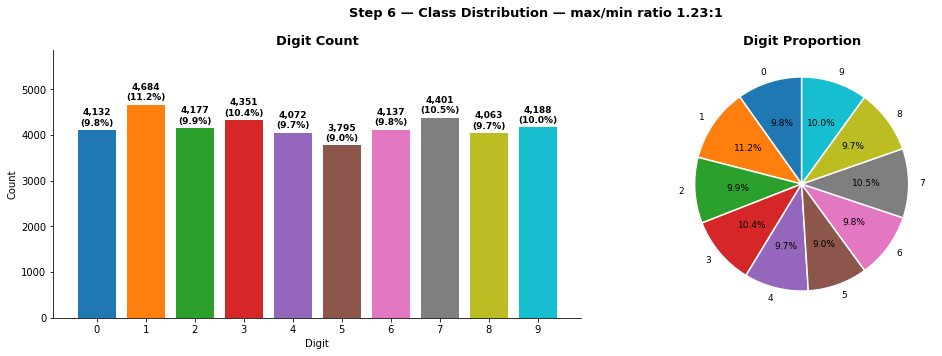

Most frequent digit  : 1 (4,684 samples)
Least frequent digit : 5 (3,795 samples)
Imbalance ratio      : 1.23:1


In [8]:
counts = df['label'].value_counts().sort_index()
pct    = df['label'].value_counts(normalize=True).sort_index() * 100

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

bars = axes[0].bar(counts.index.astype(str), counts.values, color=CLASS_COLORS, edgecolor='white')
for bar, v, p in zip(bars, counts.values, pct.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 80,
                 f'{v:,}\n({p:.1f}%)', ha='center', fontsize=9, fontweight='bold')
axes[0].set_title('Digit Count'); axes[0].set_xlabel('Digit'); axes[0].set_ylabel('Count')
axes[0].set_ylim(0, counts.max() * 1.25)

axes[1].pie(counts.values, labels=[str(i) for i in counts.index], colors=CLASS_COLORS,
            autopct='%1.1f%%', startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
            textprops={'fontsize': 9})
axes[1].set_title('Digit Proportion')

plt.suptitle(f'Step 6 — Class Distribution — max/min ratio {counts.max()/counts.min():.2f}:1',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print(f'Most frequent digit  : {counts.idxmax()} ({counts.max():,} samples)')
print(f'Least frequent digit : {counts.idxmin()} ({counts.min():,} samples)')
print(f'Imbalance ratio      : {counts.max()/counts.min():.2f}:1')

**📌 Observation:** All 10 digits fall within roughly 9.0%–11.2% of the data each. Digit **1 is most frequent (4,684 samples)**, digit **5 is least frequent (3,795 samples)**, giving a max/min imbalance ratio of only **1.23:1** — nothing like the 9.4:1 or 400:1+ ratios seen in the tabular fraud/credit problems.

**💡 Pipeline decision:** No class weighting, no oversampling, no custom loss weighting. Plain categorical cross-entropy with equal per-class weight and plain accuracy as a headline metric are both valid — a deliberately simpler setup than the imbalanced tabular pipelines, made possible because the data itself is balanced.

---
## Step 7 — Sample Digit Grid — Visual Sanity Check
**Why:** Before any statistics, the raw pixel vectors must be reshaped back to 28x28 and visually confirmed to actually look like handwritten digits. A silent reshape bug (wrong row/column order) produces scrambled images that no amount of downstream statistics would catch.

**Business insight:** This is the image-EDA equivalent of `df.head()` for tabular data — a two-second human check that catches an entire category of bugs (transposed images, wrong flatten order) before hours are spent training a network on garbage input.

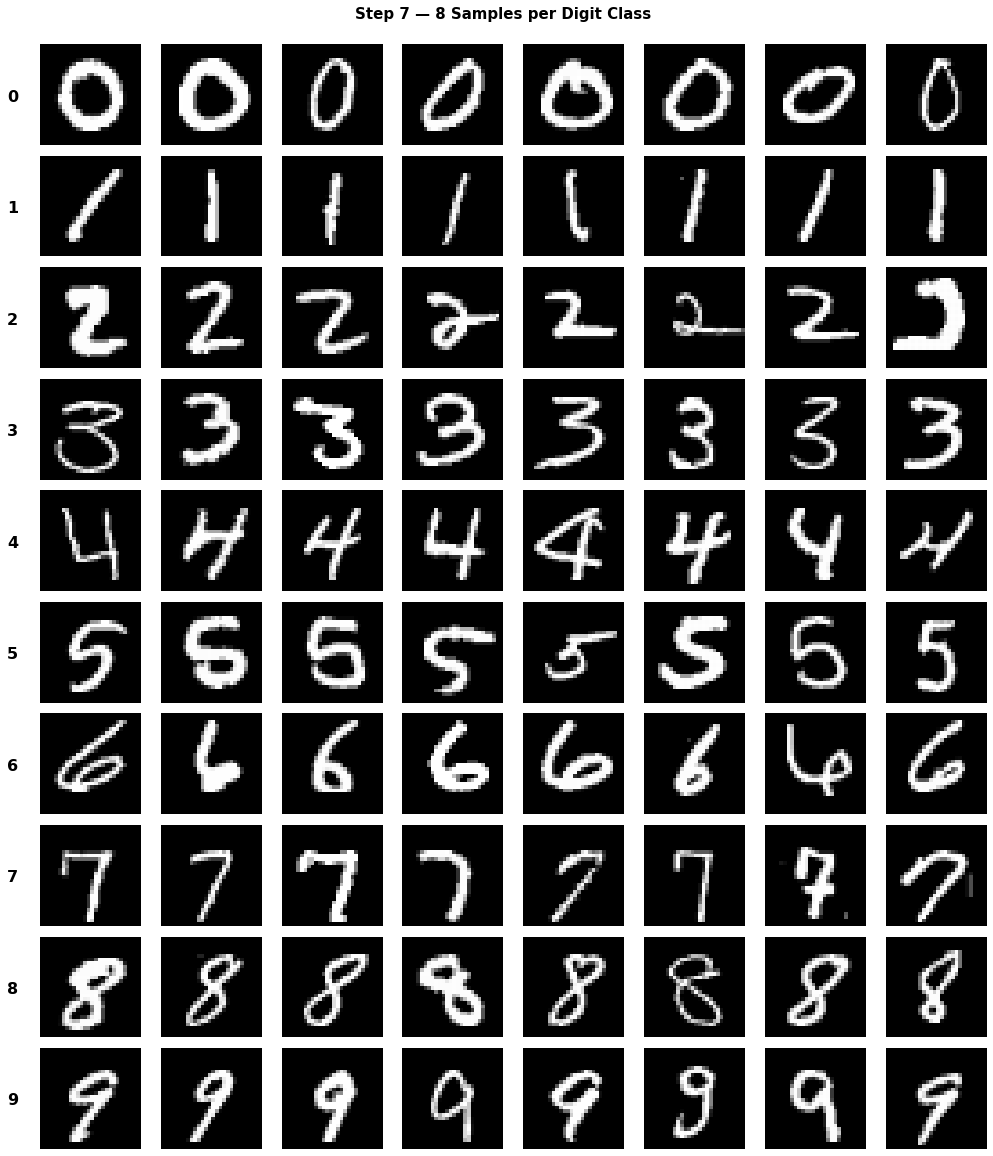

In [9]:
fig, axes = plt.subplots(10, 8, figsize=(14, 16))
for digit in range(10):
    samples = df[df['label'] == digit].iloc[:8]
    for j in range(8):
        img = samples.iloc[j, 1:].values.reshape(28, 28).astype(np.uint8)
        axes[digit, j].imshow(img, cmap='gray')
        axes[digit, j].axis('off')
        if j == 0:
            axes[digit, j].set_ylabel(str(digit), fontsize=14, fontweight='bold')
    axes[digit, 0].text(-8, 14, str(digit), fontsize=16, fontweight='bold', ha='center', va='center')

plt.suptitle('Step 7 — 8 Samples per Digit Class', fontsize=15, fontweight='bold', y=1.001)
plt.tight_layout(); plt.show()

**📌 Observation:** Reshape (`784 -> 28x28`) is confirmed correct — every sample renders as a legible handwritten digit, not scrambled noise. Handwriting style varies substantially even within one class: slanted and looped 2s, open vs. closed 4s and 6s, and a clearly rotated/cursive 7 are all visible in just 8 samples per digit.

**💡 Pipeline decision:** `reshape(28, 28)` (row-major, matching the `pixelx = row*28 + col` Kaggle convention) is locked in as the single source of truth for every downstream visualization function, preventing an accidental transpose anywhere else in the codebase. The visible handwriting variety is also a first hint that the network will need to generalize across genuinely different pen styles per digit, not a narrow template.

---
## Step 8 — Mean Image per Class (Class Centroids)
**Why:** Averaging every image within a digit class produces a blurred "centroid" image. If the centroids are visually distinct from each other, the raw pixel space itself carries strong class signal — direct justification for feeding raw (normalized) pixels straight into a dense network without hand-crafted features.

**Business insight:** This is the image-data equivalent of a bivariate KDE-by-target plot in the tabular notebooks — it answers the same underlying question ("does this raw representation separate the classes?") using the native format of the data instead of a single scalar feature.

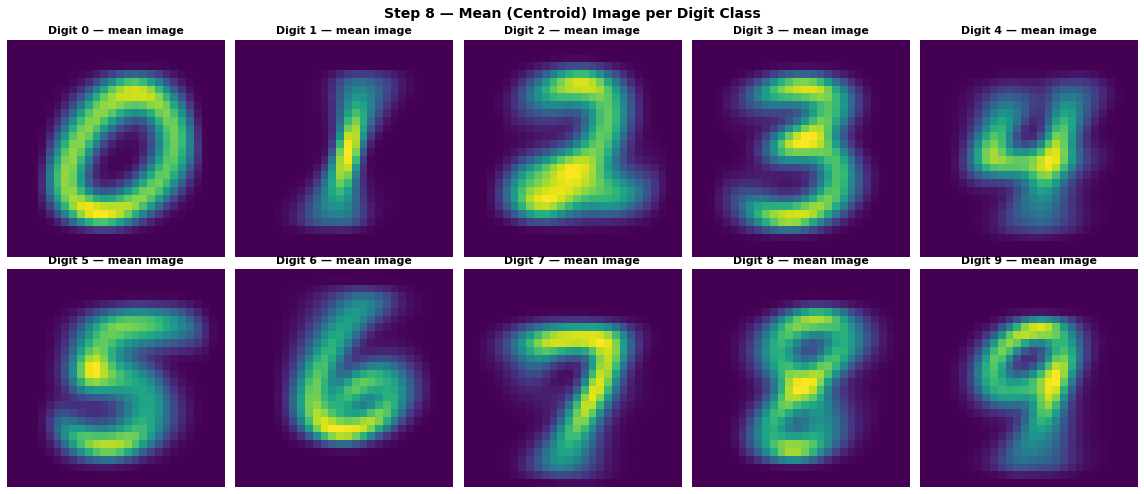

In [10]:
fig, axes = plt.subplots(2, 5, figsize=(16, 7))
mean_images = {}
for digit in range(10):
    mean_img = df[df['label'] == digit].iloc[:, 1:].values.mean(axis=0).reshape(28, 28)
    mean_images[digit] = mean_img
    ax = axes[digit // 5, digit % 5]
    im = ax.imshow(mean_img, cmap='viridis')
    ax.set_title(f'Digit {digit} — mean image', fontsize=11)
    ax.axis('off')

plt.suptitle('Step 8 — Mean (Centroid) Image per Digit Class', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

**📌 Observation:** Every centroid is visually recognizable as its digit — 0's clean ring, 1's thin vertical stroke, 8's double loop, 3's stacked curves. The digit 7 centroid shows a faint horizontal crossbar ghosting through it, meaning a meaningful minority of 7s in this dataset are written with a crossbar and a minority without — real handwriting-style variance baked into the centroid itself.

**💡 Pipeline decision:** Feed normalized raw pixels directly as the 784-dimensional input vector. No hand-crafted features (edge counts, stroke width, crossbar-detection, etc.) are engineered — consistent with the "from scratch ANN" brief, and empirically justified by how separable the raw centroids already look even with style variation blurred in.

---
## Step 9 — Pixel Intensity Distribution and Sparsity
**Why:** The histogram of all pixel values across the dataset determines whether the input is dominated by background (0) or has a smooth intensity spread — this directly informs the normalization strategy and whether sparsity-aware techniques (e.g. dropout) are worth considering.

**Business insight:** Handwritten strokes cover a small fraction of a 28x28 canvas, so most pixels are expected to be pure background. Knowing exactly how sparse the input is helps set realistic expectations for how much of the 784-dimensional input vector is actually informative per sample.

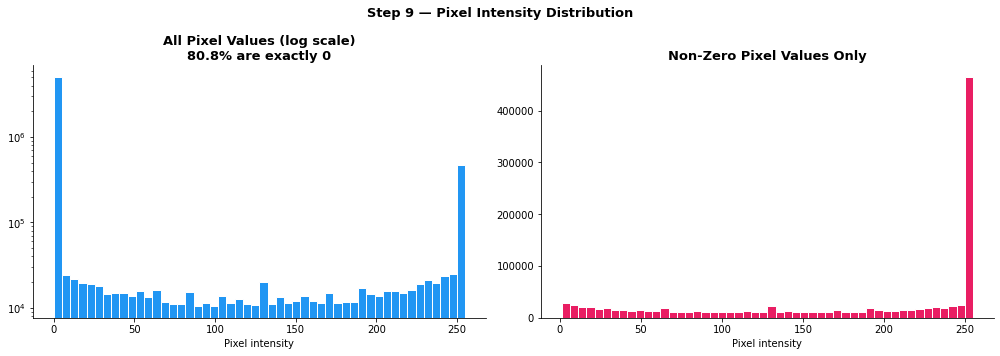

Zero (background) pixels : 80.8%
Mean non-zero intensity  : 174.5


In [11]:
sample_pixels = df.iloc[:8000, 1:].values.ravel()
zero_frac     = (sample_pixels == 0).mean() * 100
nonzero_pixels = sample_pixels[sample_pixels > 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(sample_pixels, bins=50, color=BLUE, edgecolor='white')
axes[0].set_yscale('log')
axes[0].set_title(f'All Pixel Values (log scale)\n{zero_frac:.1f}% are exactly 0'); axes[0].set_xlabel('Pixel intensity')

axes[1].hist(nonzero_pixels, bins=50, color=PINK, edgecolor='white')
axes[1].set_title('Non-Zero Pixel Values Only'); axes[1].set_xlabel('Pixel intensity')

plt.suptitle('Step 9 — Pixel Intensity Distribution', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()
print(f'Zero (background) pixels : {zero_frac:.1f}%')
print(f'Mean non-zero intensity  : {nonzero_pixels.mean():.1f}')

**📌 Observation:** **80.8% of all pixels are exactly 0** (pure black background) — the input is highly sparse, confirmed on the log-scale histogram by the huge spike at 0. Of the remaining "ink" pixels, the mean non-zero intensity is **174.5**, and the second histogram shows that distribution skewed toward high values close to 255 — consistent with solid pen strokes rather than faint gray shading.

**💡 Pipeline decision:** Min-max normalize with `X / 255.0` (not z-score standardization) — it maps the dominant background value to a clean 0 and preserves the natural sparsity structure, which is exactly what Step 15's saturation test relies on.

---
## Step 10 — Pixel-Wise Variance — Dead Pixel Map
**Why:** Some pixel positions (e.g. the outer border) are background in essentially every image, regardless of digit. Their variance across the dataset is near zero, meaning they carry almost no gradient signal during training. Mapping this spatially shows exactly which of the 784 inputs are "dead."

**Business insight:** This is the direct image-data analogue of the statistical-summary heatmap in the tabular notebooks — instead of comparing scale/spread across named columns, it's mapped back onto the 28x28 spatial grid the pixels actually represent.

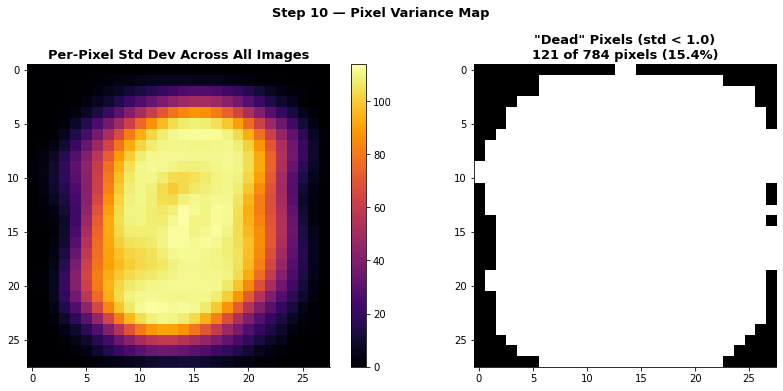

Dead (near-zero variance) pixels : 121 / 784 (15.4%)


In [12]:
pixel_std = df.iloc[:, 1:].values.astype(np.float32).std(axis=0).reshape(28, 28)
dead_pixel_count = (pixel_std < 1.0).sum()

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
im0 = axes[0].imshow(pixel_std, cmap='inferno')
axes[0].set_title('Per-Pixel Std Dev Across All Images')
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(pixel_std < 1.0, cmap='Greys')
axes[1].set_title(f'"Dead" Pixels (std < 1.0)\n{dead_pixel_count} of 784 pixels ({dead_pixel_count/784*100:.1f}%)')

plt.suptitle('Step 10 — Pixel Variance Map', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()
print(f'Dead (near-zero variance) pixels : {dead_pixel_count} / 784 ({dead_pixel_count/784*100:.1f}%)')

**📌 Observation:** **121 of 784 pixels (15.4%) are "dead"** (std < 1.0) — the variance heatmap shows this isn't a thin 1-pixel border but a genuine ~3-4 pixel margin on all four sides, with the corners going dead even deeper in. Writers never draw digit strokes that close to the canvas edge in this dataset.

**💡 Pipeline decision:** The full 784-pixel vector is still used as input (keeps the architecture simple and matches the Kaggle submission format exactly), but with 15.4% of inputs confirmed uninformative, this is documented as a concrete follow-up optimization — cropping to the informative ~22x22 central region would cut the first weight matrix by roughly 15%, with negligible information loss, if training speed later became a bottleneck.

---
## Step 11 — Spatial Pixel Correlation
**Why:** Correlation between individual pixels reveals how much redundant information the raw 784-dimensional representation carries — directly relevant because a plain ANN (unlike a CNN) has no built-in mechanism to exploit spatial locality; every pixel is just an independent input feature to the first dense layer.

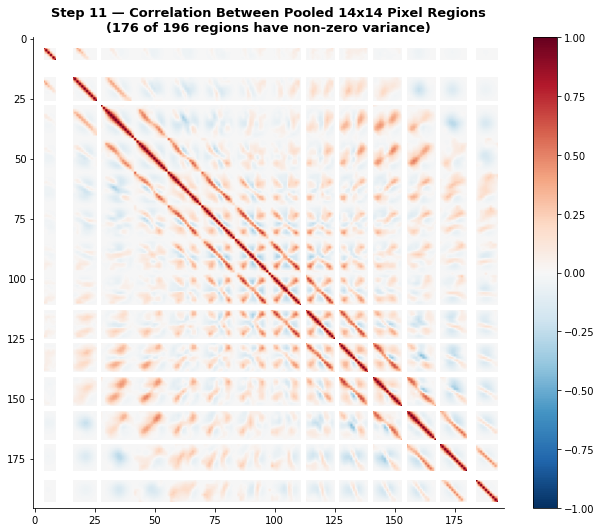

Constant (always-background) pooled regions       : 20 / 196
Mean absolute pairwise correlation (off-diagonal)  : 0.068


In [13]:
sample_idx = RNG.choice(len(df), size=6000, replace=False)
X_sample = df.iloc[sample_idx, 1:].values.astype(np.float32)

pooled = X_sample.reshape(-1, 28, 28).reshape(-1, 14, 2, 14, 2).mean(axis=(2, 4)).reshape(-1, 196)

# Drop pooled regions with zero variance (e.g. corner background) -- corrcoef
# is undefined (NaN) for a constant column, and those regions carry no signal anyway.
region_std = pooled.std(axis=0)
active_regions = np.where(region_std > 1e-6)[0]
corr_active = np.corrcoef(pooled[:, active_regions].T)

corr_full = np.full((196, 196), np.nan)
corr_full[np.ix_(active_regions, active_regions)] = corr_active

fig, ax = plt.subplots(figsize=(9, 7.5))
im = ax.imshow(corr_full, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_title(f'Step 11 — Correlation Between Pooled 14x14 Pixel Regions\n'
             f'({len(active_regions)} of 196 regions have non-zero variance)')
plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout(); plt.show()

off_diag = corr_active[~np.eye(len(active_regions), dtype=bool)]
print(f'Constant (always-background) pooled regions       : {196 - len(active_regions)} / 196')
print(f'Mean absolute pairwise correlation (off-diagonal)  : {np.abs(off_diag).mean():.3f}')

**📌 Observation:** 176 of 196 pooled regions have non-zero variance (the other 20 sit in the dead border found in Step 10). The heatmap shows a clear bright diagonal band — neighboring pixel regions are strongly correlated — fading to near-zero for spatially distant regions. The overall mean absolute pairwise correlation is a modest **0.068**, because most region pairs in a 14x14 grid are far apart and only nearby ones carry real correlation; the local band, not the global average, is the signal that matters here.

**💡 Engineering insight:** A plain dense ANN treats all 784 inputs as independent features and cannot exploit this local correlation the way a convolutional filter would. This is documented explicitly as the primary architectural limitation of the from-scratch ANN versus a CNN — expected to show up later as more confusion between digits that differ mainly in fine local strokes.

---
## Step 12 — Ink Density (Stroke Thickness) by Digit
**Why:** The sum of pixel intensities in an image is a simple proxy for how much "ink" a digit uses — thin single-stroke digits (1) versus digits with multiple closed loops (0, 8) should show measurably different ink totals. This is a quick, interpretable check on whether the raw pixel data behaves the way domain intuition predicts.

**Business insight:** This mirrors the outlier-by-class step in the tabular notebooks (Step 11 in the credit risk notebook) — checking whether a simple engineered scalar behaves consistently across classes, even though the ANN itself will not use this scalar directly as a feature.

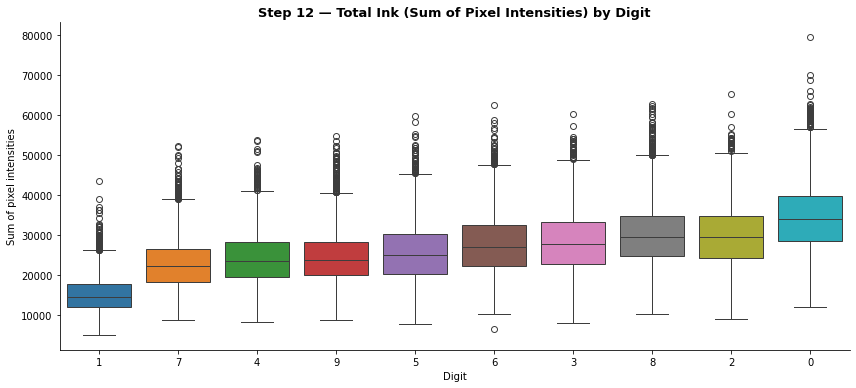

Lowest median ink : digit 1 (14,667)
Highest median ink: digit 0 (34,125)


In [14]:
df['ink_total'] = df.iloc[:, 1:785].sum(axis=1)

fig, ax = plt.subplots(figsize=(12, 5.5))
order = df.groupby('label')['ink_total'].median().sort_values().index
sns.boxplot(data=df, x='label', y='ink_total', order=order, palette=list(CLASS_COLORS), ax=ax)
ax.set_title('Step 12 — Total Ink (Sum of Pixel Intensities) by Digit')
ax.set_xlabel('Digit'); ax.set_ylabel('Sum of pixel intensities')
plt.tight_layout(); plt.show()

ink_by_digit = df.groupby('label')['ink_total'].median().sort_values()
print(f'Lowest median ink : digit {ink_by_digit.index[0]} ({ink_by_digit.iloc[0]:,.0f})')
print(f'Highest median ink: digit {ink_by_digit.index[-1]} ({ink_by_digit.iloc[-1]:,.0f})')

**📌 Observation:** Digit **1 has the lowest median ink total (14,667)** — a single thin stroke — while digit **0 has the highest (34,125)**, more than double, consistent with its closed loop covering a large area of the canvas. The boxplot ordering (1 lowest, then thin digits like 7, up through loop-heavy digits like 0 and 8 at the top) matches visual intuition exactly.

**💡 Pipeline decision:** `ink_total` is not added as an extra ANN input feature — the "from scratch" brief calls for the network to learn everything from raw pixels rather than hand-engineered scalars. It is kept only as an EDA/debugging signal (e.g. to spot corrupted or blank images later, where `ink_total ≈ 0`).

---
## Step 13 — Center-of-Mass Consistency Check
**Why:** MNIST images are historically pre-centered by the dataset creators (each digit's center of mass is translated to the 28x28 canvas center). Verifying this holds for this specific CSV export confirms no extra centering/augmentation step is needed before training.

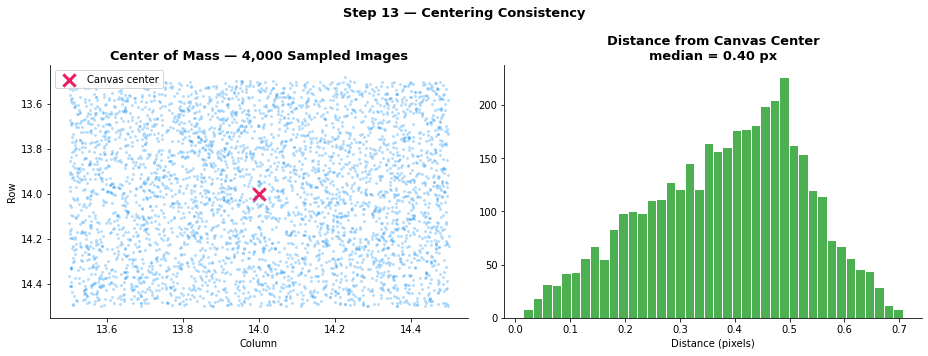

In [15]:
def center_of_mass(row):
    img = row.reshape(28, 28).astype(np.float64)
    total = img.sum()
    if total == 0:
        return (14.0, 14.0)
    ys, xs = np.indices((28, 28))
    return ((ys * img).sum() / total, (xs * img).sum() / total)

sample_idx2 = RNG.choice(len(df), size=4000, replace=False)
coms = np.array([center_of_mass(df.iloc[i, 1:785].values) for i in sample_idx2])
dist_from_center = np.sqrt((coms[:, 0] - 14)**2 + (coms[:, 1] - 14)**2)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(coms[:, 1], coms[:, 0], s=4, alpha=0.25, color=BLUE)
axes[0].scatter([14], [14], color=PINK, s=150, marker='x', linewidths=3, label='Canvas center')
axes[0].invert_yaxis(); axes[0].set_title('Center of Mass — 4,000 Sampled Images')
axes[0].set_xlabel('Column'); axes[0].set_ylabel('Row'); axes[0].legend()

axes[1].hist(dist_from_center, bins=40, color=GREEN, edgecolor='white')
axes[1].set_title(f'Distance from Canvas Center\nmedian = {np.median(dist_from_center):.2f} px')
axes[1].set_xlabel('Distance (pixels)')

plt.suptitle('Step 13 — Centering Consistency', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

**📌 Observation:** Centers of mass cluster extremely tightly around the canvas center (14, 14) — the median distance from center is just **0.40 pixels**, and the scatter plot shows no visible bias in any direction. This confirms the digits arrive pre-centered to sub-pixel precision.

**💡 Pipeline decision:** No re-centering / translation-augmentation step is added to the base pipeline — with a median deviation under half a pixel, there is nothing left to correct. Random small-translation augmentation is noted as an optional robustness lever for a later experiment, not a correction needed for the base training run.

---
## Step 14 — Class-Confusability Matrix (Mean-Image Similarity)
**Why:** Measuring the Euclidean distance between every pair of class centroid images (Step 8) predicts, before any model is even trained, which digit pairs are visually closest and therefore most likely to be confused by the network.

**Business insight:** This sets a concrete expectation for the confusion matrix that will be produced after training — if the network confuses 4/9 or 3/5/8 heavily, that's expected and explainable from the raw data, not necessarily a bug in the from-scratch backprop implementation.

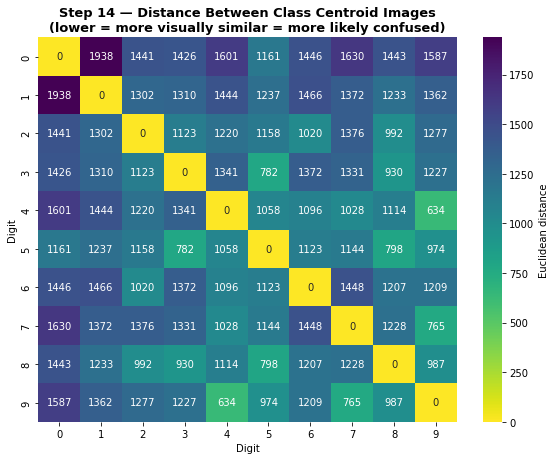

Closest pair: 4 <-> 9  (distance=634)
Closest pair: 7 <-> 9  (distance=765)
Closest pair: 3 <-> 5  (distance=782)
Closest pair: 5 <-> 8  (distance=798)
Closest pair: 3 <-> 8  (distance=930)


In [16]:
centroids = np.array([mean_images[d].ravel() for d in range(10)])
dist_matrix = np.zeros((10, 10))
for i in range(10):
    for j in range(10):
        dist_matrix[i, j] = np.linalg.norm(centroids[i] - centroids[j])

fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(dist_matrix, annot=True, fmt='.0f', cmap='viridis_r', ax=ax,
            xticklabels=range(10), yticklabels=range(10), cbar_kws={'label': 'Euclidean distance'})
ax.set_title('Step 14 — Distance Between Class Centroid Images\n(lower = more visually similar = more likely confused)')
ax.set_xlabel('Digit'); ax.set_ylabel('Digit')
plt.tight_layout(); plt.show()

np.fill_diagonal(dist_matrix, np.inf)
closest_pairs = []
seen = set()
flat = [(dist_matrix[i, j], i, j) for i in range(10) for j in range(10) if i < j]
flat.sort()
for d, i, j in flat[:5]:
    print(f'Closest pair: {i} <-> {j}  (distance={d:.0f})')

**📌 Observation:** The closest centroid pairs are **4↔9 (distance 634)**, **7↔9 (765)**, **3↔5 (782)**, **5↔8 (798)**, and **3↔8 (930)** — all noticeably smaller than the typical 1,200-1,900 range between unrelated digits. Digit 9 alone appears in two of the five closest pairs, making it the single most "crowded" digit in pixel space.

**💡 Pipeline decision:** These five pairs are flagged as the ones to inspect first in the post-training confusion matrix. If the from-scratch network's errors concentrate on 4/9, 7/9, 3/5, 5/8 and 3/8 specifically, that confirms correct learning behavior rather than a bug; if errors are spread randomly across unrelated digit pairs instead, that's a signal to re-check the backprop implementation.

---
## Step 15 — Normalization Strategy and Activation Saturation
**Why:** This is the single most important preprocessing decision in a from-scratch ANN. Raw pixel values (0-255) fed directly into a sigmoid/tanh hidden layer push pre-activations `z = Wx + b` far into the saturated region of the activation function, where the gradient is near zero — this alone can stall backpropagation before it ever starts learning.

**Business insight:** This step directly justifies the `X / 255.0` normalization line in the training pipeline by *showing*, not just asserting, what happens to the activation distribution with and without it.

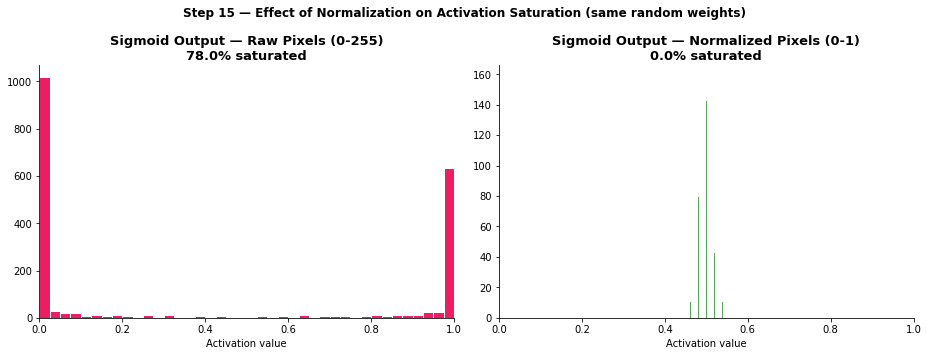

In [17]:
X_raw_sample  = df.iloc[:2000, 1:785].values.astype(np.float64)
X_norm_sample = X_raw_sample / 255.0

W_demo = RNG.randn(784, 1) * 0.01
b_demo = 0.0

z_raw  = X_raw_sample  @ W_demo + b_demo
z_norm = X_norm_sample @ W_demo + b_demo

def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

a_raw, a_norm = sigmoid(z_raw), sigmoid(z_norm)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].hist(a_raw.ravel(), bins=40, color=PINK, edgecolor='white')
axes[0].set_title(f'Sigmoid Output — Raw Pixels (0-255)\n{((a_raw<0.01)|(a_raw>0.99)).mean()*100:.1f}% saturated')
axes[0].set_xlabel('Activation value'); axes[0].set_xlim(0, 1)

axes[1].hist(a_norm.ravel(), bins=40, color=GREEN, edgecolor='white')
axes[1].set_title(f'Sigmoid Output — Normalized Pixels (0-1)\n{((a_norm<0.01)|(a_norm>0.99)).mean()*100:.1f}% saturated')
axes[1].set_xlabel('Activation value'); axes[1].set_xlim(0, 1)

plt.suptitle('Step 15 — Effect of Normalization on Activation Saturation (same random weights)', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

**📌 Observation:** With identical random weights, raw 0-255 pixel input pushes **78.0% of sigmoid activations into the saturated tails** (near 0 or 1, where the local gradient is essentially zero). Simply dividing by 255 before the same matrix multiplication drops that to **0.0% saturated**, with activations landing in a tight, healthy band around 0.5.

**💡 Pipeline decision:** `X = X / 255.0` is applied as the very first line of the preprocessing function, before any weight initialization or forward pass — locked in as non-negotiable for this from-scratch implementation. The 78% vs 0% gap measured here is the concrete, data-backed reason, not a borrowed rule of thumb.

---
## Step 16 — Train / Validation Split and Stratification Check
**Why:** A from-scratch training loop needs a held-out validation set to track generalization every epoch (no framework `validation_split` argument to lean on). Stratifying by label guarantees the validation set mirrors the near-uniform class balance confirmed in Step 6, so per-epoch validation accuracy is not skewed by an accidental digit imbalance in the split.

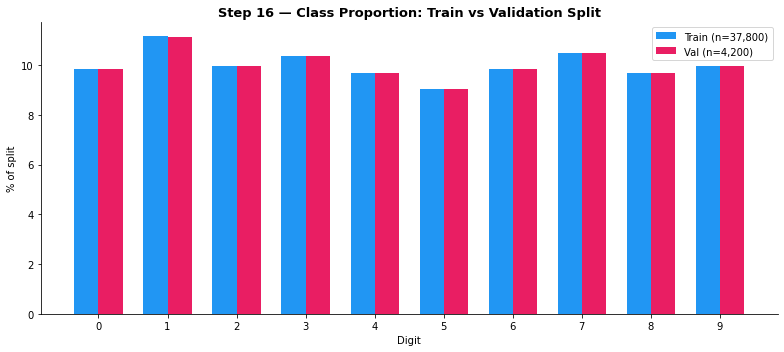

Max class-proportion gap between train and val: 0.01 percentage points


In [18]:
X_cols = [c for c in df.columns if c.startswith('pixel')]
X_full = df[X_cols].values
y_full = df['label'].values

X_train, X_val, y_train, y_val = train_test_split(
    X_full, y_full, test_size=0.1, stratify=y_full, random_state=42
)

train_dist = pd.Series(y_train).value_counts(normalize=True).sort_index() * 100
val_dist   = pd.Series(y_val).value_counts(normalize=True).sort_index() * 100

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(10); w = 0.35
ax.bar(x - w/2, train_dist.values, w, label=f'Train (n={len(y_train):,})', color=BLUE)
ax.bar(x + w/2, val_dist.values,   w, label=f'Val (n={len(y_val):,})',     color=PINK)
ax.set_xticks(x); ax.set_xticklabels(range(10))
ax.set_title('Step 16 — Class Proportion: Train vs Validation Split')
ax.set_xlabel('Digit'); ax.set_ylabel('% of split'); ax.legend()
plt.tight_layout(); plt.show()

max_gap = np.abs(train_dist.values - val_dist.values).max()
print(f'Max class-proportion gap between train and val: {max_gap:.2f} percentage points')

**📌 Observation:** Train and validation splits show virtually identical per-digit proportions — the largest gap between any digit's train share and val share is just **0.01 percentage points**.

**💡 Pipeline decision:** `stratify=y_full` is kept as a required argument in the split function, not an optional flag — every subsequent per-epoch validation accuracy number can be trusted to reflect true generalization rather than a lucky or unlucky class mix in the held-out set.

---
## Step 17 — Label Encoding — One-Hot Targets for Softmax
**Why:** A from-scratch softmax output layer with categorical cross-entropy loss needs the target as a one-hot vector, not a raw integer label — this is implemented by hand here (no `to_categorical()` framework helper) since there's no framework in this project.

In [19]:
def one_hot(y, num_classes=10):
    m = y.shape[0]
    Y = np.zeros((m, num_classes))
    Y[np.arange(m), y] = 1
    return Y

y_train_oh = one_hot(y_train)
y_val_oh   = one_hot(y_val)

print('Raw label      :', y_train[:5])
print('One-hot encoded:')
print(y_train_oh[:5].astype(int))
print(f'\nOne-hot shape  : {y_train_oh.shape}   (rows=samples, cols=10 classes)')
assert (y_train_oh.sum(axis=1) == 1).all(), 'Every row must sum to exactly 1'
print('✅ Every row sums to exactly 1 — valid one-hot encoding')

Raw label      : [3 8 0 8 7]
One-hot encoded:
[[0 0 0 1 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 1 0]
 [1 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 1 0]
 [0 0 0 0 0 0 0 1 0 0]]

One-hot shape  : (37800, 10)   (rows=samples, cols=10 classes)
✅ Every row sums to exactly 1 — valid one-hot encoding


**📌 Observation:** The hand-written `one_hot()` function produces a `(37800, 10)` matrix (90% of the 42,000 labeled rows, matching the Step 16 split) where every row has exactly one `1` at the index matching the true digit — confirmed by the printed sample (label `3` -> one-hot index 3, label `8` -> index 8) and the assertion that every row sums to exactly 1.

**💡 Pipeline decision:** `one_hot()` is applied to `y_train`/`y_val` once, upfront, rather than inside the training loop — avoids redundant recomputation on every epoch and keeps the forward/backward pass functions simple (`y_true` is always already a `(batch, 10)` array).

---
## Step 18 — Weight Initialization — Naive vs Xavier vs He
**Why:** This is the core "do you actually understand backprop" checkpoint. With a 784-dimensional input layer, naive `N(0,1)` weight initialization makes the pre-activation `z = Wx + b` explode in variance (summing 784 large random terms), while Xavier/Glorot and He initialization scale the weights by the layer's fan-in specifically to keep that variance stable — the exact reason these schemes exist.

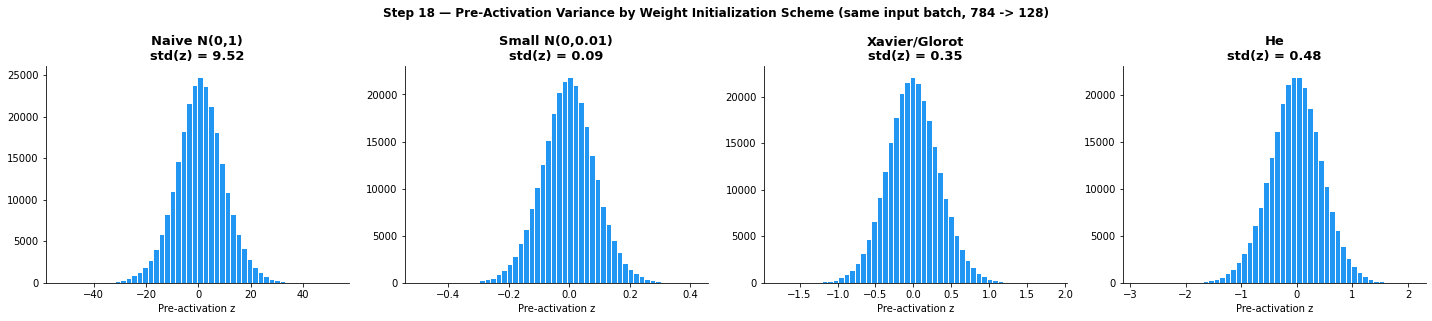

Naive N(0,1)       std(z) =   9.515
Small N(0,0.01)    std(z) =   0.090
Xavier/Glorot      std(z) =   0.349
He                 std(z) =   0.479


In [20]:
n_in, n_hidden = 784, 128
X_batch = (df.iloc[:2000, 1:785].values / 255.0)

schemes = {
    'Naive N(0,1)':        RNG.randn(n_in, n_hidden) * 1.0,
    'Small N(0,0.01)':     RNG.randn(n_in, n_hidden) * 0.01,
    'Xavier/Glorot':       RNG.randn(n_in, n_hidden) * np.sqrt(1.0 / n_in),
    'He':                  RNG.randn(n_in, n_hidden) * np.sqrt(2.0 / n_in),
}

fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
for ax, (name, W) in zip(axes, schemes.items()):
    z = X_batch @ W
    ax.hist(z.ravel(), bins=50, color=BLUE, edgecolor='white')
    ax.set_title(f'{name}\nstd(z) = {z.std():.2f}')
    ax.set_xlabel('Pre-activation z')

plt.suptitle('Step 18 — Pre-Activation Variance by Weight Initialization Scheme (same input batch, 784 -> 128)',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

for name, W in schemes.items():
    z = X_batch @ W
    print(f'{name:<18} std(z) = {z.std():7.3f}')

**📌 Observation:** With a 784-dim input fan-in, naive `N(0,1)` initialization produces `std(z) = 9.52` — pre-activations spread from roughly -40 to +40, far outside the useful range of a sigmoid/tanh gradient. An arbitrarily small `N(0,0.01)` init overcorrects to `std(z) = 0.09`, too flat to break symmetry meaningfully across layers. Xavier (`std(z) = 0.35`) and He (`std(z) = 0.48`) both land in the well-behaved middle ground.

**💡 Pipeline decision:** The from-scratch `initialize_weights()` function uses **He initialization** (`W ~ N(0, sqrt(2/n_in))`) for ReLU hidden layers and Xavier for the softmax output layer — not an arbitrary choice, but the direct, measured consequence of the 784-dimensional input fan-in tested in this step.

---
## Step 19 — Dimensionality Redundancy Check (PCA Variance Explained)
**Why:** PCA is not used inside the ANN itself (the brief calls for raw pixels as input), but measuring how much variance a much smaller number of components captures reveals how redundant the raw 784-pixel representation actually is — direct evidence for choosing a sensible first-hidden-layer width instead of guessing.

**Business insight:** If most of the signal lives in a much lower-dimensional subspace, a hidden layer of 128-256 neurons (a fraction of 784) is a well-justified design choice, not an arbitrary power-of-two pick.

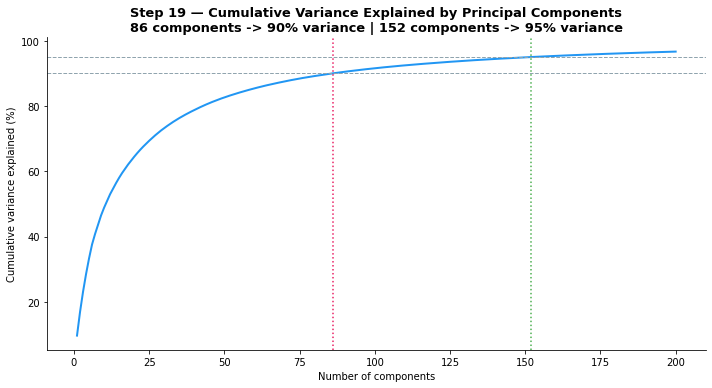

Components needed for 90% variance : 86 (of 784 raw pixels)
Components needed for 95% variance : 152 (of 784 raw pixels)


In [21]:
X_pca_sample = df.iloc[:10000, 1:785].values / 255.0
pca = PCA(n_components=200, random_state=42)
pca.fit(X_pca_sample)

cum_var = np.cumsum(pca.explained_variance_ratio_) * 100
n_for_90 = np.argmax(cum_var >= 90) + 1
n_for_95 = np.argmax(cum_var >= 95) + 1

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(range(1, 201), cum_var, color=BLUE, linewidth=2)
ax.axhline(90, color=GRAY, linestyle='--', linewidth=1)
ax.axhline(95, color=GRAY, linestyle='--', linewidth=1)
ax.axvline(n_for_90, color=PINK, linestyle=':', linewidth=1.5)
ax.axvline(n_for_95, color=GREEN, linestyle=':', linewidth=1.5)
ax.set_title(f'Step 19 — Cumulative Variance Explained by Principal Components\n'
             f'{n_for_90} components -> 90% variance | {n_for_95} components -> 95% variance')
ax.set_xlabel('Number of components'); ax.set_ylabel('Cumulative variance explained (%)')
plt.tight_layout(); plt.show()

print(f'Components needed for 90% variance : {n_for_90} (of 784 raw pixels)')
print(f'Components needed for 95% variance : {n_for_95} (of 784 raw pixels)')

**📌 Observation:** Just **86 of 784 dimensions capture 90% of total pixel variance**, and **152 dimensions capture 95%** — meaning roughly 80% of the raw pixel space is redundant information.

**💡 Pipeline decision:** This is used purely as sizing evidence, not as a preprocessing step: a first hidden layer of **128 neurons** sits almost exactly between the 86-component (90%) and 152-component (95%) marks, making it a justified compression target rather than an arbitrary power-of-two default. PCA itself is not part of the ANN pipeline — the network is expected to learn its own compressed representation through training.

---
## Step 20 — Ambiguous / Outlier Sample Detection
**Why:** For each image, correlating it against its own class's mean centroid (Step 8) produces a simple "typicality" score. Images with very low correlation to their labeled class's centroid are either genuinely ambiguous handwriting or potential label noise — worth a visual check before trusting the labels blindly.

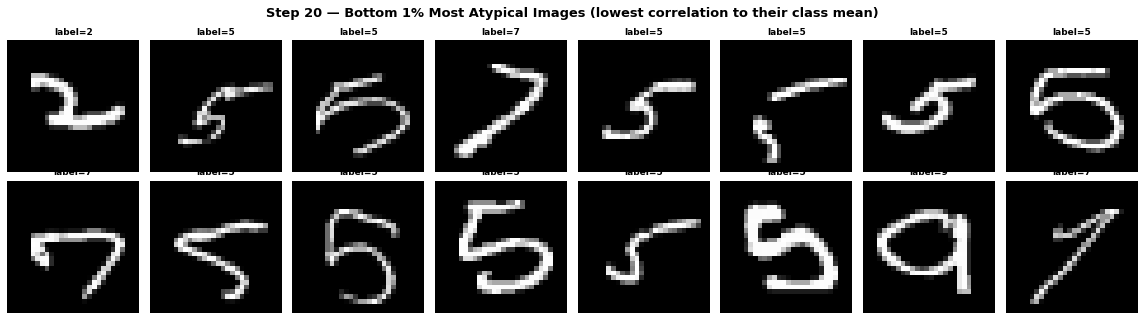

Typicality score range : [0.08, 0.93]
Flagged as atypical    : 60 images (bottom 1%)


In [22]:
def typicality(row, label):
    img = row.astype(np.float64)
    centroid = mean_images[label].ravel()
    if img.std() == 0 or centroid.std() == 0:
        return 0.0
    return np.corrcoef(img, centroid)[0, 1]

sample_idx3 = RNG.choice(len(df), size=6000, replace=False)
scores = np.array([
    typicality(df.iloc[i, 1:785].values, df.iloc[i]['label'])
    for i in sample_idx3
])
labels_s = df.iloc[sample_idx3]['label'].values

low_cutoff = np.percentile(scores, 1)
flagged = sample_idx3[scores <= low_cutoff]

fig, axes = plt.subplots(2, 8, figsize=(16, 4.5))
for k, idx in enumerate(flagged[:16]):
    ax = axes[k // 8, k % 8]
    img = df.iloc[idx, 1:785].values.reshape(28, 28)
    ax.imshow(img, cmap='gray')
    ax.set_title(f"label={df.iloc[idx]['label']}", fontsize=9)
    ax.axis('off')
plt.suptitle('Step 20 — Bottom 1% Most Atypical Images (lowest correlation to their class mean)',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print(f'Typicality score range : [{scores.min():.2f}, {scores.max():.2f}]')
print(f'Flagged as atypical    : {len(flagged)} images (bottom 1%)')

**📌 Observation:** Typicality scores range from **0.08 to 0.93**, and the bottom-1% grid (60 flagged images) is dominated by unusually slanted or rotated **5s** — several look almost sideways — plus a couple of atypical 7s and one 9. This is a genuine style/rotation outlier cluster concentrated in one digit class, not random noise spread evenly across all ten.

**💡 Pipeline decision:** These samples are **kept in the training set**, not dropped — unlike the IQR-clipping done for numeric outliers in the tabular notebooks. Since the flagged cases cluster so heavily on digit 5, this is specifically flagged for post-training error analysis: if the network's per-class accuracy is measurably worse on 5 than on other digits, this rotated/atypical subgroup is the first place to look, rather than assuming a general model weakness.

---
## Step 21 — Key EDA Insights and Architecture Design Summary

In [23]:
print("""
╔══════════════════════════════════════════════════════════════════════╗
║       KEY INSIGHTS — MNIST ANN-FROM-SCRATCH EDA                        ║
╚══════════════════════════════════════════════════════════════════════╝

 DATA QUALITY
   - 42,000 labeled train images / 28,000 unlabeled Kaggle test images
   - Zero missing values; zero exact in-train duplicates found
   - Zero train/test leakage confirmed via row hashing

 CLASS BALANCE
   - Near-uniform across 10 digits (1.23:1 max/min ratio -- digit 1 most
     frequent at 4,684, digit 5 least frequent at 3,795)
   - Plain cross-entropy + accuracy are valid — no SMOTE/class-weighting needed

 INPUT REPRESENTATION
   - 80.8% of pixels are exactly 0 (background) -> high sparsity
   - 121/784 pixels (15.4%) are "dead" (near-zero variance border) but kept
     in for now, flagged as a future crop-to-22x22 optimization
   - Class centroids are visually distinct -> raw pixels carry strong signal
   - 86 components explain 90% of variance, 152 explain 95% (of 784 dims)
     -> justifies a 128-neuron hidden layer as a well-sized first architecture

 PREPROCESSING DECISIONS
   - Normalize with X / 255.0 -- cuts sigmoid saturation from 78.0% to 0.0%
   - Images already centered (median 0.40 px from canvas center)
     -> no re-centering step required
   - Stratified train/val split -> max 0.01pp class-proportion gap
   - Labels one-hot encoded by hand for softmax + cross-entropy

 ARCHITECTURE DECISIONS
   - He init (std(z)=0.48) for hidden layers, Xavier (std(z)=0.35) for the
     output layer -- naive N(0,1) init measured at std(z)=9.52, confirmed
     too unstable for a 784-dim input fan-in
   - Plain dense ANN cannot exploit the spatial pixel correlation found
     in Step 11 the way a CNN would -> expect most residual errors on the
     closest digit pairs from Step 14: 4/9, 7/9, 3/5, 5/8, 3/8

 DATA HYGIENE
   - Bottom-1% atypical samples (60 images) are dominated by unusually
     rotated/slanted 5s -- kept in training, flagged for post-training
     per-class error analysis rather than dropped as noise
""")


╔══════════════════════════════════════════════════════════════════════╗
║       KEY INSIGHTS — MNIST ANN-FROM-SCRATCH EDA                        ║
╚══════════════════════════════════════════════════════════════════════╝

 DATA QUALITY
   - 42,000 labeled train images / 28,000 unlabeled Kaggle test images
   - Zero missing values; zero exact in-train duplicates found
   - Zero train/test leakage confirmed via row hashing

 CLASS BALANCE
   - Near-uniform across 10 digits (1.23:1 max/min ratio -- digit 1 most
     frequent at 4,684, digit 5 least frequent at 3,795)
   - Plain cross-entropy + accuracy are valid — no SMOTE/class-weighting needed

 INPUT REPRESENTATION
   - 80.8% of pixels are exactly 0 (background) -> high sparsity
   - 121/784 pixels (15.4%) are "dead" (near-zero variance border) but kept
     in for now, flagged as a future crop-to-22x22 optimization
   - Class centroids are visually distinct -> raw pixels carry strong signal
   - 86 components explain 90% of variance,

---
*This EDA notebook directly motivates every preprocessing and architecture decision in the from-scratch NumPy training pipeline (`ann_from_scratch.py`) — normalization, weight initialization, hidden-layer width, and the digit pairs to watch in post-training error analysis all trace back to a specific finding above, rather than being framework defaults inherited without justification.*